# Fase 3: Preparación y modelado de datos

Proyecto: Análisis BI Airbnb NYC - Equipo 10

Registros originales: 48,895
Columnas originales: 16

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


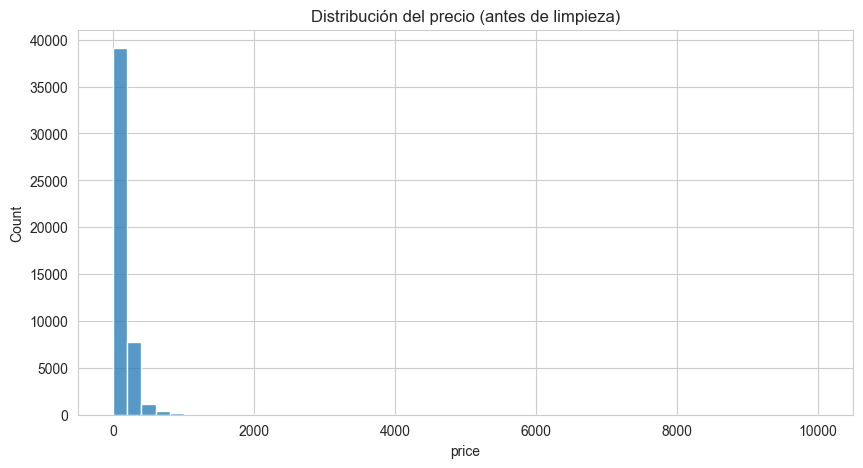


Registros duplicados encontrados: 0
Registros después de eliminar duplicados: 48,895

Valores nulos antes:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Valores nulos después:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood  

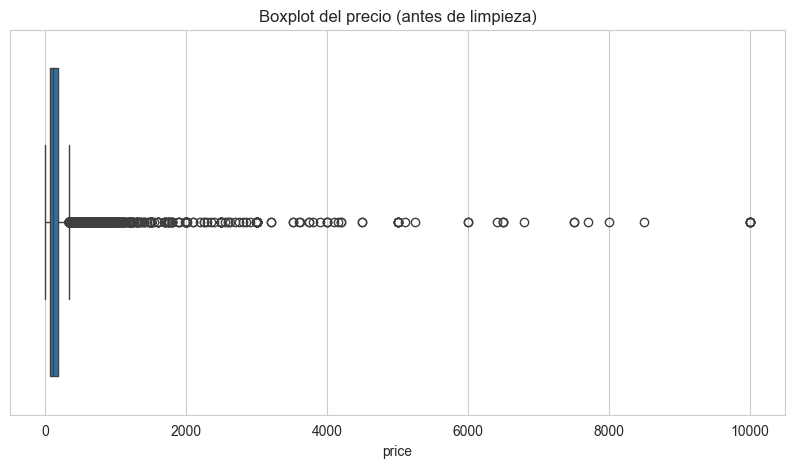


Percentil 99 del precio: 799.0
Registros después de eliminar outliers: 48,410


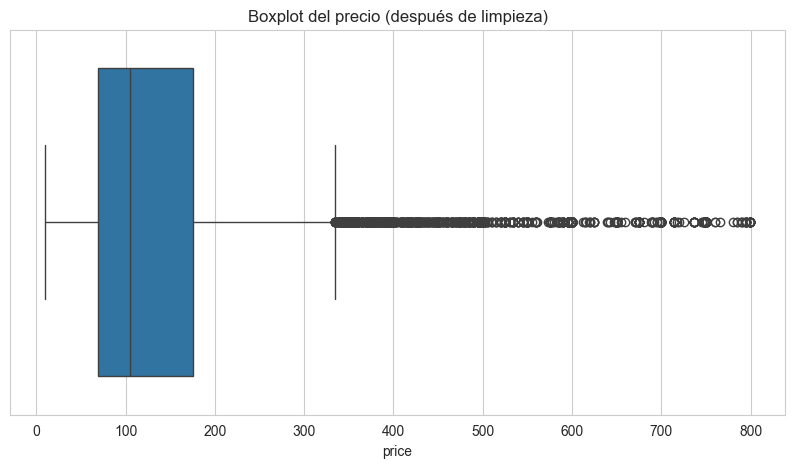


Columnas finales seleccionadas:
['neighbourhood_group', 'neighbourhood', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'host_type']

Dimensiones finales del dataset:
(48410, 9)

Valores nulos finales:
neighbourhood_group    0
neighbourhood          0
room_type              0
price                  0
minimum_nights         0
number_of_reviews      0
reviews_per_month      0
availability_365       0
host_type              0
dtype: int64

Resumen estadístico final:


,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365
count,48410.000000,48410.000000,48410.000000,48410.000000,48410.000000
mean,137.575170,6.979508,23.412663,1.096716,112.094195
std,103.780081,20.293249,44.700109,1.601074,131.258152
min,10.000000,1.000000,0.000000,0.000000,0.000000
25%,69.000000,1.000000,1.000000,0.040000,0.000000
50%,105.000000,3.000000,5.000000,0.380000,44.000000
75%,175.000000,5.000000,24.000000,1.600000,224.000000
max,799.000000,1250.000000,629.000000,58.500000,365.000000



Resumen por distrito:


,neighbourhood_group,price,number_of_reviews,availability_365
0,Bronx,83.862925,28315,165.757130
1,Brooklyn,115.921519,485138,99.872349
2,Manhattan,172.901886,451606,110.823902
3,Queens,94.104779,156807,144.140000
4,Staten Island,94.241192,11541,198.872629



Resumen por tipo de alojamiento:


,room_type,price,number_of_reviews
0,Entire home/apt,189.100272,23.043242
1,Private room,83.394747,24.175473
2,Shared room,64.203301,16.706342



Dataset limpio guardado correctamente.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

# 1. CARGA DEL DATASET
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')

print(f"Registros originales: {df.shape[0]:,}")
print(f"Columnas originales: {df.shape[1]}")
df.head()

# 2. EXPLORACIÓN INICIAL

print("\nInformación general del dataset:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

# Distribución inicial del precio
plt.figure()
sns.histplot(df['price'], bins=50)
plt.title('Distribución del precio (antes de limpieza)')
plt.show()


# 3. LIMPIEZA DE DATOS

# Eliminamos duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados encontrados: {duplicados}")

df = df.drop_duplicates()
print(f"Registros después de eliminar duplicados: {df.shape[0]:,}")

# Tratamiento de valores nulos
print("\nValores nulos antes:")
print(df.isnull().sum())

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

print("\nValores nulos después:")
print(df.isnull().sum())

# Eliminamos columnas no relevantes
columnas_eliminar = ['id', 'host_name']
df = df.drop(columns=columnas_eliminar)

print(f"\nColumnas eliminadas: {columnas_eliminar}")

# 4. TRANSFORMACIÓN DE DATOS

# Creamos variable de tipo de anfitrión
df['host_type'] = df['calculated_host_listings_count'].apply(
    lambda x: 'Profesional' if x > 1 else 'Ocasional'
)

print("\nDistribución de tipo de anfitrión:")
print(df['host_type'].value_counts())

# Convertimos la fecha
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# 5. ANÁLISIS Y TRATAMIENTO DE OUTLIERS

print("\nEstadísticas de precio antes del filtrado:")
print(df['price'].describe())

# Boxplot antes
plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio (antes de limpieza)')
plt.show()

# Eliminamos precios no válidos
df = df[df['price'] > 0]

# Percentil 99
p99 = df['price'].quantile(0.99)
print(f"\nPercentil 99 del precio: {p99}")

# Filtrado de outliers extremos
df = df[df['price'] <= p99]

print(f"Registros después de eliminar outliers: {df.shape[0]:,}")

# Boxplot después
plt.figure()
sns.boxplot(x=df['price'])
plt.title('Boxplot del precio (después de limpieza)')
plt.show()

# 6. SELECCIÓN DE VARIABLES

columnas_finales = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365',
    'host_type'
]

df = df[columnas_finales]

print("\nColumnas finales seleccionadas:")
print(df.columns.tolist())

# 7. VALIDACIÓN FINAL

print("\nDimensiones finales del dataset:")
print(df.shape)

print("\nValores nulos finales:")
print(df.isnull().sum())

print("\nResumen estadístico final:")
display(df.describe())

# 8. ESTRUCTURA PARA ANÁLISIS

# Agrupación por distrito
df_grouped = df.groupby('neighbourhood_group').agg({
    'price': 'mean',
    'number_of_reviews': 'sum',
    'availability_365': 'mean'
}).reset_index()

print("\nResumen por distrito:")
display(df_grouped)

# Agrupación por tipo de alojamiento
df_room = df.groupby('room_type').agg({
    'price': 'mean',
    'number_of_reviews': 'mean'
}).reset_index()

print("\nResumen por tipo de alojamiento:")
display(df_room)


# 9. EXPORTACIÓN DEL DATASET LIMPIO

df.to_csv('../data/processed/airbnb_clean.csv', index=False)

print("\nDataset limpio guardado correctamente.")